# Klasyczna homografia boiska — potok krok po kroku

Notebook pokazuje **E2E wyznaczenie homografii** na pojedynczej klatce metodą
klasyczną (bez uczenia), w oparciu o klasę `ClassicalHomographyV2`.

Każdy krok = jedna komórka + wizualizacja pośredniego wyniku:

| Krok | Metoda klasy | Wynik |
|------|--------------|-------|
| 1 | `segment_field` | maska pola gry |
| 2 | `extract_line_mask` | maska białych linii |
| 3 | `detect_segments` | odcinki (HoughLinesP) |
| 4 | `merge_collinear` | pełne linie |
| 5 | `group_two_directions` | 2 grupy kierunkowe + punkty zbiegu |
| 6 | `estimate_homography` | macierz H (VP-RANSAC) |
| 7 | `refine_homography` | dostrojona H |
| — | `get_homography` | całość E2E |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.calibration.classical_homography_v2 import ClassicalHomographyV2

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['figure.dpi'] = 100


def show(img_bgr=None, mask=None, title='', ax=None):
    """Pomocnik: pokazuje obraz BGR lub maskę."""
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(14, 8))
    if mask is not None:
        ax.imshow(mask, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
    if own:
        plt.show()


def overlay_pitch(image, H, cal, color=(0, 255, 255), thickness=2):
    """Rysuje model linii boiska na obrazie wg homografii H (pixel->metry)."""
    vis = image.copy()
    if H is None:
        return vis
    H_inv = np.linalg.inv(H)
    for polyline in cal.pitch_lines:
        pts = []
        for xm, ym in polyline:
            p = H_inv @ np.array([xm, ym, 1.0])
            if abs(p[2]) < 1e-10:
                continue
            p /= p[2]
            pts.append((int(round(p[0])), int(round(p[1]))))
        for k in range(len(pts) - 1):
            cv2.line(vis, pts[k], pts[k + 1], color, thickness)
    return vis

## Krok 0 — wybór i wczytanie klatki

Obraz: 1920x1080  (000001.jpg)
[ClassicalHomographyV2] Inicjalizacja (obraz 1920x1080, RANSAC 5000 iter, min_score 0.12)


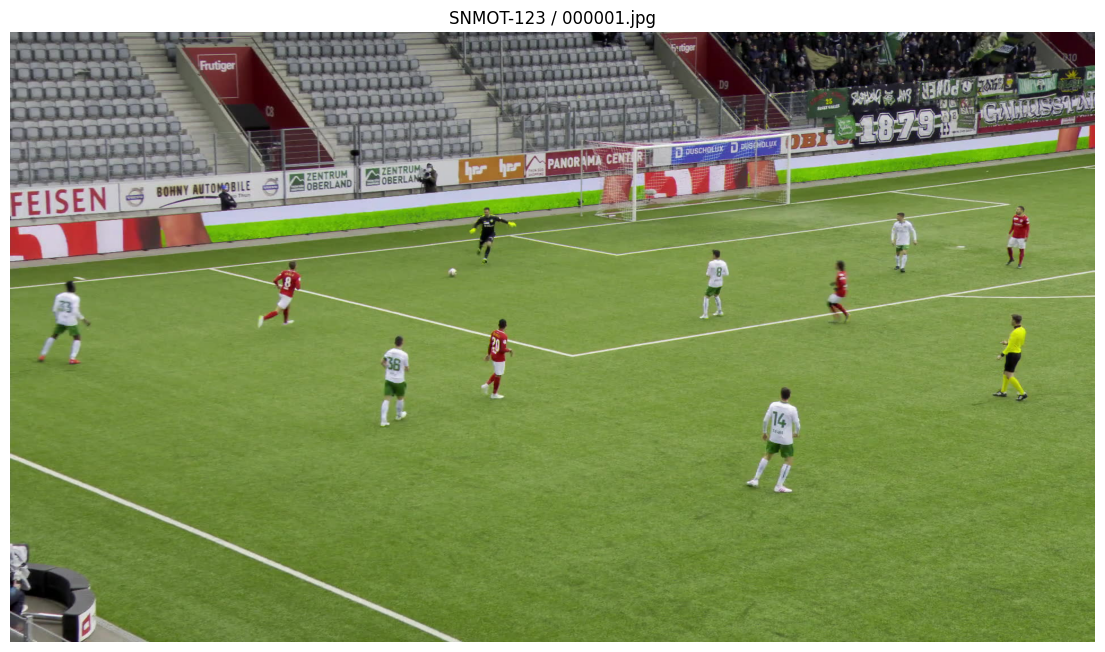

In [2]:
SEQUENCE = "SNMOT-123"
FRAME_NUM = 1

frame_path = (PROJECT_ROOT / "data" / "tracking_dataset" / "tracking" / "test"
              / SEQUENCE / "img1" / f"{FRAME_NUM:06d}.jpg")
image = cv2.imread(str(frame_path))
assert image is not None, f"Nie udało się wczytać: {frame_path}"

h, w = image.shape[:2]
print(f"Obraz: {w}x{h}  ({frame_path.name})")

# Kalibrator — verbose pokazuje komunikaty z każdego etapu
cal = ClassicalHomographyV2(image_width=w, image_height=h,
                            ransac_iterations=5000, min_score=0.12, verbose=True)

show(image, title=f"{SEQUENCE} / {frame_path.name}")

## Krok 1 — segmentacja pola gry

Zielona murawa → największy kontur → wypukła otoczka (convex hull) → erozja
(odcina banery reklamowe tuż przy krawędzi boiska).

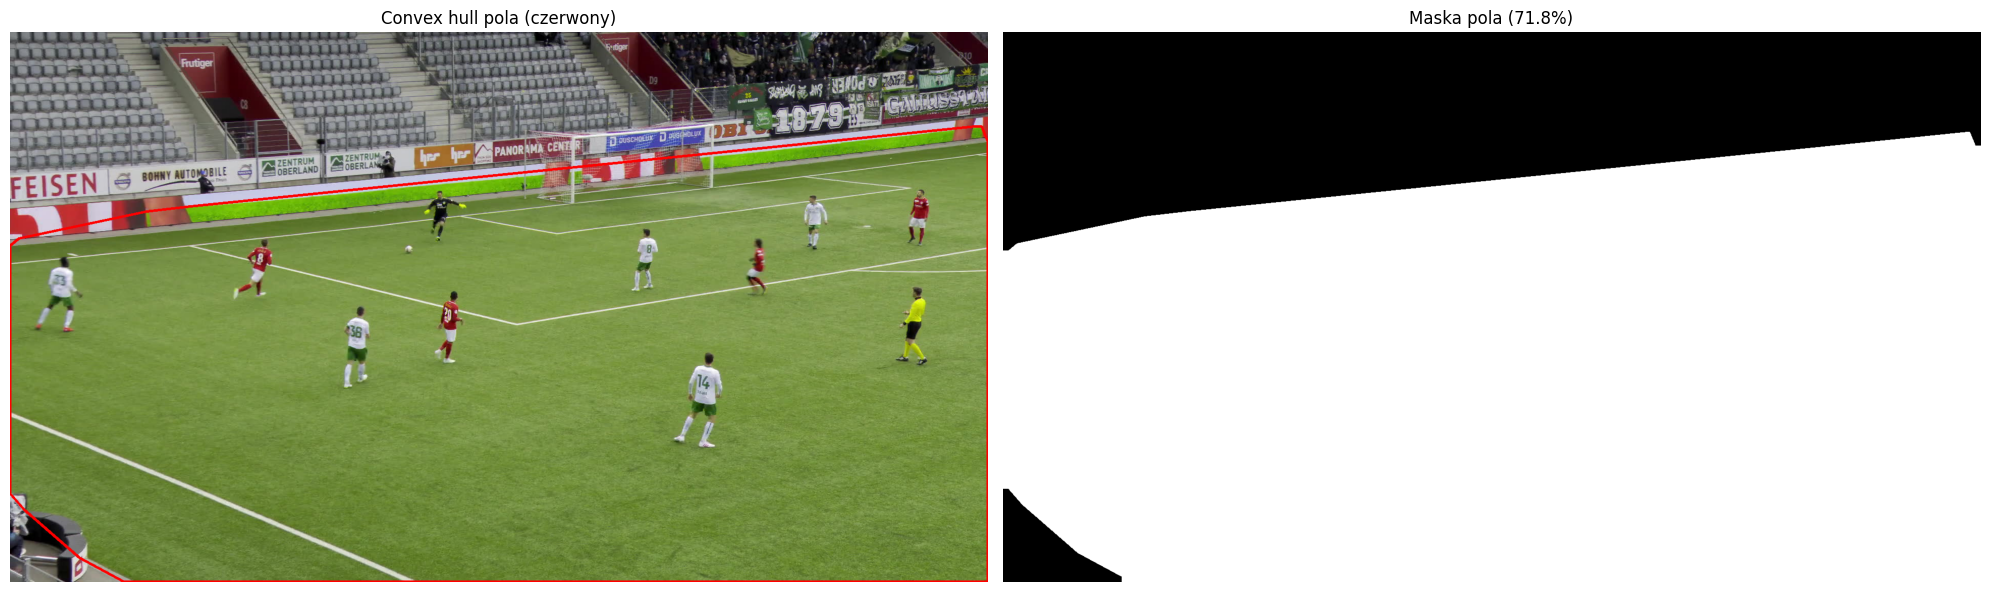

In [3]:
field_mask, hull = cal.segment_field(image)

vis_hull = image.copy()
if hull is not None:
    cv2.polylines(vis_hull, [hull], True, (0, 0, 255), 3)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
show(vis_hull, title="Convex hull pola (czerwony)", ax=axes[0])
show(mask=field_mask, title=f"Maska pola ({np.mean(field_mask > 0) * 100:.1f}%)", ax=axes[1])
plt.tight_layout(); plt.show()

## Krok 2 — maska białych linii

Białe piksele w obrębie pola + filtr kształtu (odrzucamy napisy, numery,
bloby — zostają cienkie, wydłużone struktury = linie).

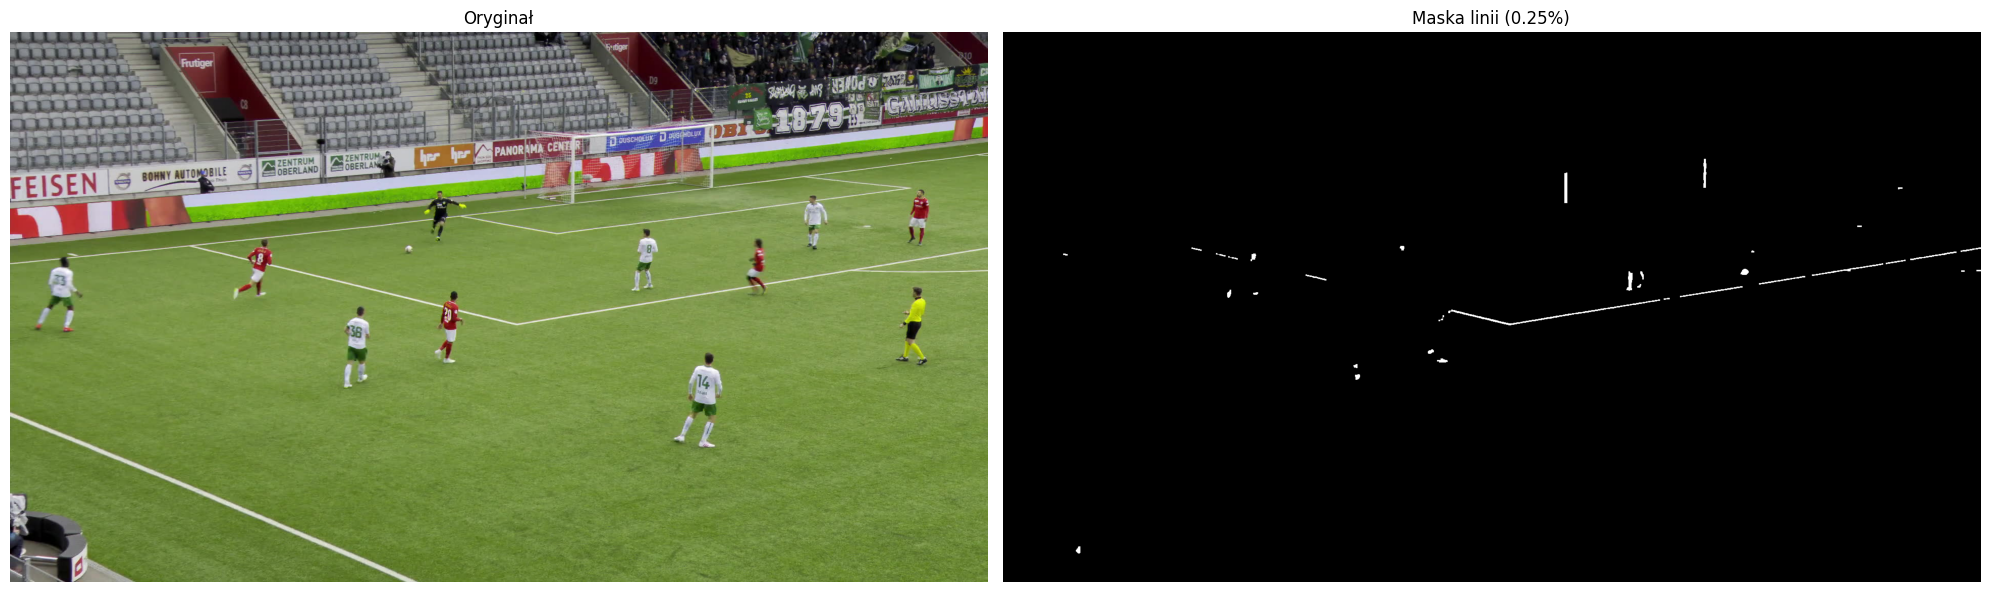

In [4]:
line_mask = cal.extract_line_mask(image, field_mask)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
show(image, title="Oryginał", ax=axes[0])
show(mask=line_mask, title=f"Maska linii ({np.mean(line_mask > 0) * 100:.2f}%)", ax=axes[1])
plt.tight_layout(); plt.show()

## Krok 3 — detekcja odcinków (HoughLinesP)

Wykryto odcinków: 25


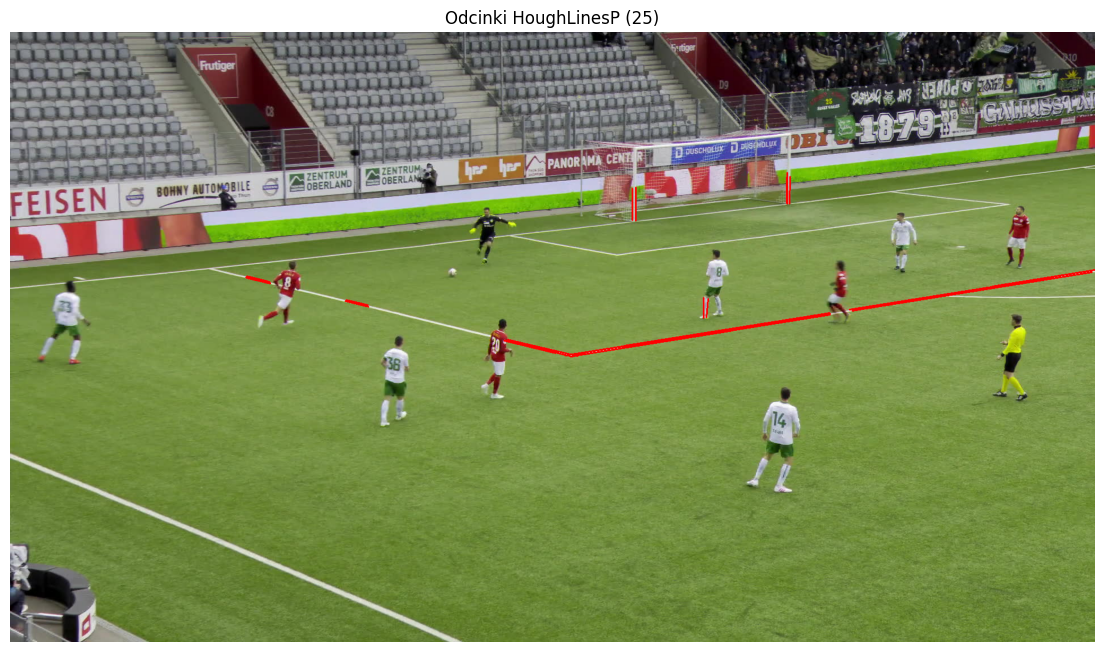

In [5]:
segments = cal.detect_segments(line_mask)
print(f"Wykryto odcinków: {len(segments)}")

vis_seg = image.copy()
for x1, y1, x2, y2 in segments:
    cv2.line(vis_seg, (x1, y1), (x2, y2), (0, 0, 255), 2)
show(vis_seg, title=f"Odcinki HoughLinesP ({len(segments)})")

## Krok 4 — scalanie kolinearnych odcinków w pełne linie

Scalone linie: 6
  0: kąt=171.0°  długość=  2537px  odcinków=8
  1: kąt= 13.4°  długość=   589px  odcinków=9
  2: kąt= 90.4°  długość=   149px  odcinków=3
  3: kąt= 90.0°  długość=   115px  odcinków=2
  4: kąt= 90.0°  długość=    36px  odcinków=1
  5: kąt= 95.2°  długość=    33px  odcinków=1


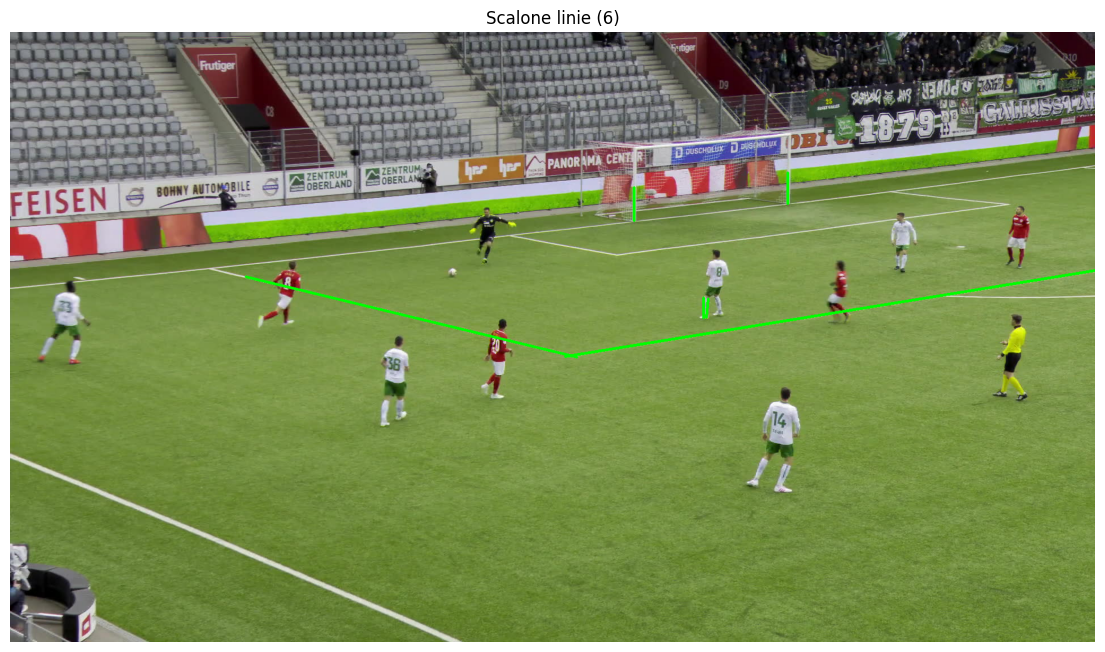

In [6]:
merged = cal.merge_collinear(segments)
print(f"Scalone linie: {len(merged)}")
for i, m in enumerate(merged):
    print(f"  {i}: kąt={m['angle']:5.1f}°  długość={m['total_length']:6.0f}px  "
          f"odcinków={m['n_segments']}")

vis_merged = image.copy()
for m in merged:
    p1 = tuple(np.round(m['p1']).astype(int))
    p2 = tuple(np.round(m['p2']).astype(int))
    cv2.line(vis_merged, p1, p2, (0, 255, 0), 3)
show(vis_merged, title=f"Scalone linie ({len(merged)})")

## Krok 5 — grupowanie w 2 kierunki + punkty zbiegu

Linie dzielimy na 2 grupy kierunkowe (wzdłuż / w poprzek boiska).
Z każdej grupy liczymy **punkt zbiegu** (vanishing point) — przecięcie
linii równoległych w przestrzeni rzutowej.

Grupa A: 2 linii, Grupa B: 4 linii
  VP A: (992, 574) px
  VP B: (977, 76500) px


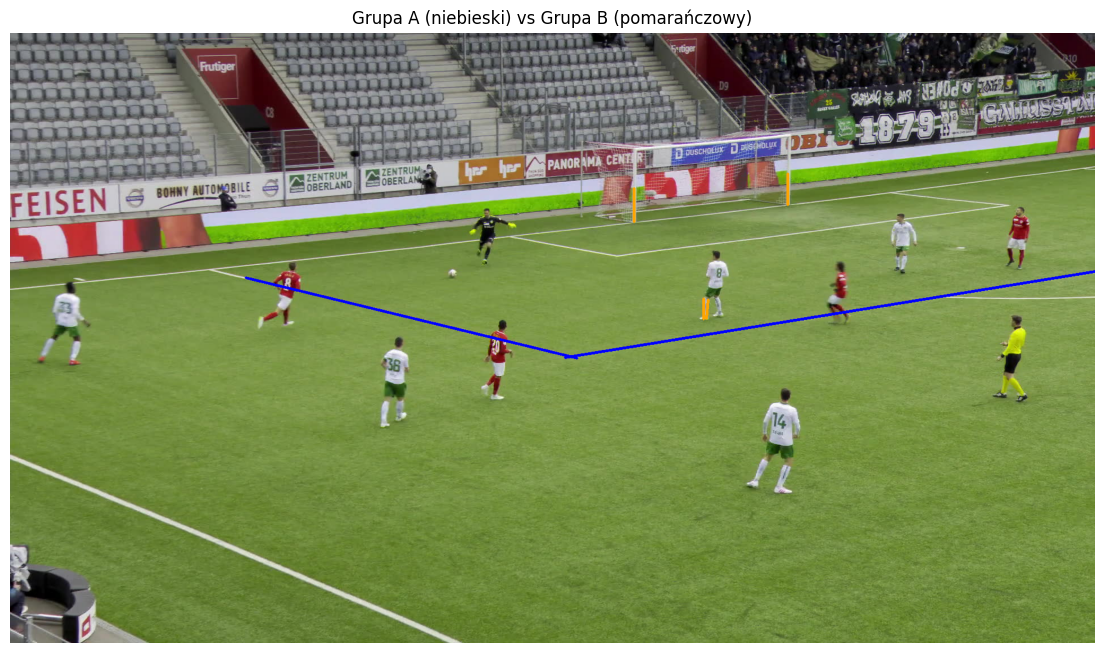

In [7]:
group_a, group_b = cal.group_two_directions(merged)
print(f"Grupa A: {len(group_a)} linii, Grupa B: {len(group_b)} linii")

vp_a = cal.compute_vanishing_point(group_a)
vp_b = cal.compute_vanishing_point(group_b)
for name, vp in (("A", vp_a), ("B", vp_b)):
    if vp is not None and abs(vp[2]) > 1e-10:
        v = vp / vp[2]
        print(f"  VP {name}: ({v[0]:.0f}, {v[1]:.0f}) px")
    else:
        print(f"  VP {name}: w nieskończoności (linie ~równoległe w obrazie)")

vis_groups = image.copy()
for m in group_a:
    cv2.line(vis_groups, tuple(np.round(m['p1']).astype(int)),
             tuple(np.round(m['p2']).astype(int)), (255, 0, 0), 3)
for m in group_b:
    cv2.line(vis_groups, tuple(np.round(m['p1']).astype(int)),
             tuple(np.round(m['p2']).astype(int)), (0, 165, 255), 3)
show(vis_groups, title="Grupa A (niebieski) vs Grupa B (pomarańczowy)")

## Krok 6 — estymacja homografii (VP-RANSAC)

Mając 2 punkty zbiegu, wystarczą **2 korespondencje punktowe**
(przecięcie linii w obrazie ↔ znany keypoint boiska), aby wyznaczyć H.
RANSAC losuje pary korespondencji i wybiera tę o najwyższym F1.

VP-RANSAC: F1 = 0.000


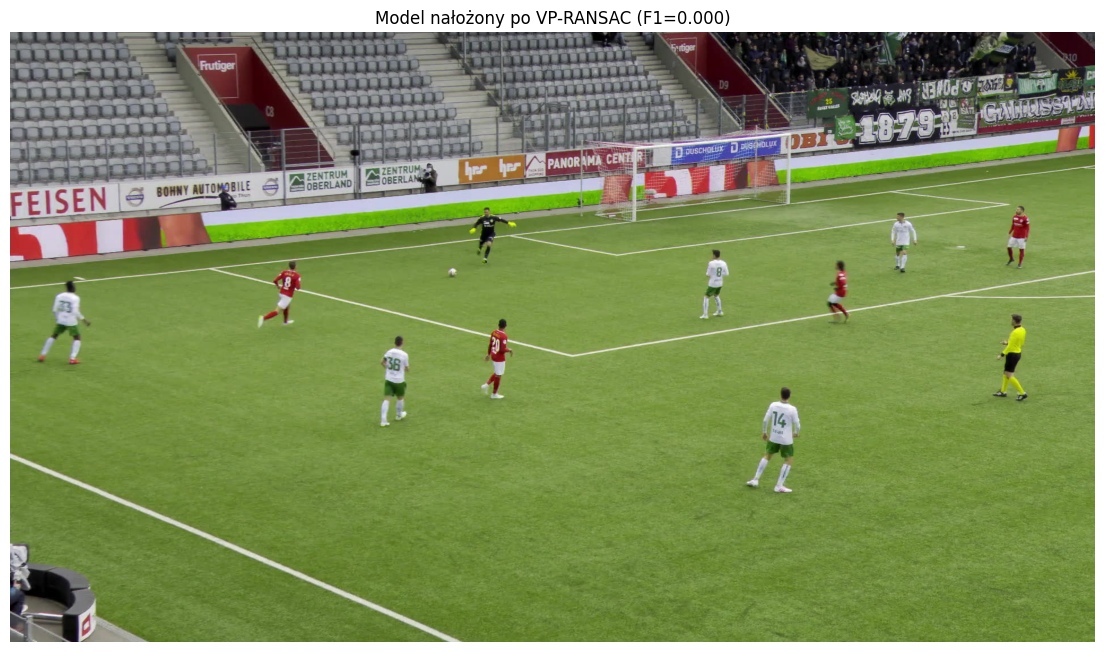

In [8]:
H_est, score_est = cal.estimate_homography(line_mask, group_a, group_b)
print(f"VP-RANSAC: F1 = {score_est:.3f}")

vis_est = overlay_pitch(image, H_est, cal)
show(vis_est, title=f"Model nałożony po VP-RANSAC (F1={score_est:.3f})")

## Krok 7 — refinement (Nelder-Mead)

Lokalna optymalizacja H, maksymalizująca F1 dopasowania modelu do maski linii.

In [9]:
if H_est is not None:
    H_ref, score_ref = cal.refine_homography(H_est, line_mask)
    print(f"Refinement: F1 {score_est:.3f} -> {score_ref:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    show(overlay_pitch(image, H_est, cal), title=f"Przed (F1={score_est:.3f})", ax=axes[0])
    show(overlay_pitch(image, H_ref, cal), title=f"Po refinement (F1={score_ref:.3f})", ax=axes[1])
    plt.tight_layout(); plt.show()
else:
    print("Brak H z poprzedniego kroku — pomijam refinement")
    H_ref = None

Brak H z poprzedniego kroku — pomijam refinement


## Krok 8 — całość E2E (`get_homography`) + projekcja

Jedno wywołanie spinające wszystkie kroki. Na koniec rzutujemy kilka
punktów obrazu na współrzędne boiska, żeby sprawdzić sensowność H.

In [10]:
H = cal.get_homography(str(frame_path))

if H is not None:
    print("\nMacierz H (pixel -> metry):")
    print(np.array2string(H, precision=4, suppress_small=True))

    # Projekcja narożników i środka obrazu na boisko
    test_pts = [(w // 2, h // 2), (0, h), (w, h), (w // 2, h)]
    print("\nProjekcja punktów obrazu -> boisko [m]:")
    for px, py in test_pts:
        xy = cal.project_point_to_pitch((px, py), H)
        print(f"  ({px:4d}, {py:4d}) -> {xy}")

    show(overlay_pitch(image, H, cal, thickness=2),
         title="Wynik E2E — model boiska nałożony na klatkę")
else:
    print("Nie udało się wyznaczyć homografii")

[ClassicalHomographyV2] Odcinki: 25, linie: 6, grupy: 2/4
[ClassicalHomographyV2] VP-RANSAC F1: 0.000
[ClassicalHomographyV2] Nie znaleziono H (F1=0.000)
Nie udało się wyznaczyć homografii
